In [1]:
import os
from pathlib import Path
import sys

import matplotlib.pyplot as plt

workspace_root = Path.cwd()
plot_module_dir = workspace_root / "plot" if (workspace_root / "plot").exists() else workspace_root
if str(plot_module_dir) not in sys.path:
    sys.path.insert(0, str(plot_module_dir))

from training_metrics import extract_metrics, has_values, read_validation_log

In [2]:
log_file = "/Volumes/data/Users/Matous/terpene_synthases/output/dplm/training/TPS_dplm_150m_stage3_grid_lr1em5_wu2000_lend1em06_winit1em08_loratrue/train.log"

log = read_validation_log(log_file)

In [3]:
checkpoints = list(range(1_000, 22_001, 1_000))

In [4]:
save_to = os.path.join(os.path.dirname(os.path.abspath(log_file)), "training_plots")
os.makedirs(save_to, exist_ok=True)


In [5]:
parsed = extract_metrics(log)

epochs = parsed["epochs"]
global_steps = parsed["global_steps"]
available_metrics = parsed["available_metrics"]
series = parsed["series"]

losses = series.get("loss", [float("nan")] * len(epochs))
nll_loss = series.get("nll_loss", [float("nan")] * len(epochs))
ppl = series.get("ppl", [float("nan")] * len(epochs))
ppl_best = series.get("ppl_best", [float("nan")] * len(epochs))
acc = series.get("acc", [float("nan")] * len(epochs))
acc_best = series.get("acc_best", [float("nan")] * len(epochs))
acc_median = series.get("acc_median", [float("nan")] * len(epochs))
acc_median_best = series.get("acc_median_best", [float("nan")] * len(epochs))

print("Available validation metrics:", available_metrics)
print(epochs)
print(global_steps)
print(losses)
print(nll_loss)
print(ppl)
print(ppl_best)

Available validation metrics: ['loss', 'nll_loss', 'ppl', 'ppl_best']
[0, 9, 19, 29, 39, 49, 59, 69, 79, 89, 99, 109, 119, 129, 139, 149, 159, 169, 179, 189, 199, 209, 219, 229, 239, 249, 259, 269, 279, 289, 299, 309, 319, 329, 339, 349, 359, 369, 379, 389, 399, 409, 419, 429, 439, 449, 459, 469, 479, 489, 499, 509, 519, 529, 539, 549, 559, 569, 579, 589, 599, 609, 619, 629, 639, 649, 659, 669, 679, 689, 699, 709, 719, 729, 739, 749, 759, 769, 779, 789, 799, 809, 819, 829, 839, 849, 859, 869, 879, 889, 899, 909, 919, 929, 939, 949, 959, 969, 979, 989, 999, 1009, 1019, 1029, 1039, 1049, 1059, 1069, 1079, 1089, 1099, 1109, 1119, 1129, 1139, 1149, 1159, 1169, 1179, 1189, 1199, 1209, 1219, 1229, 1239, 1249, 1259, 1269, 1279, 1289, 1299, 1309, 1319, 1329, 1339, 1349, 1359, 1369, 1379, 1389, 1399, 1409, 1419, 1429, 1439, 1449, 1459, 1469, 1479, 1489, 1499, 1509, 1519, 1529, 1539, 1549, 1559, 1569, 1579, 1589, 1599, 1609, 1619, 1629, 1639, 1649, 1659, 1669, 1679, 1689, 1699, 1709, 1719]
[0, 1

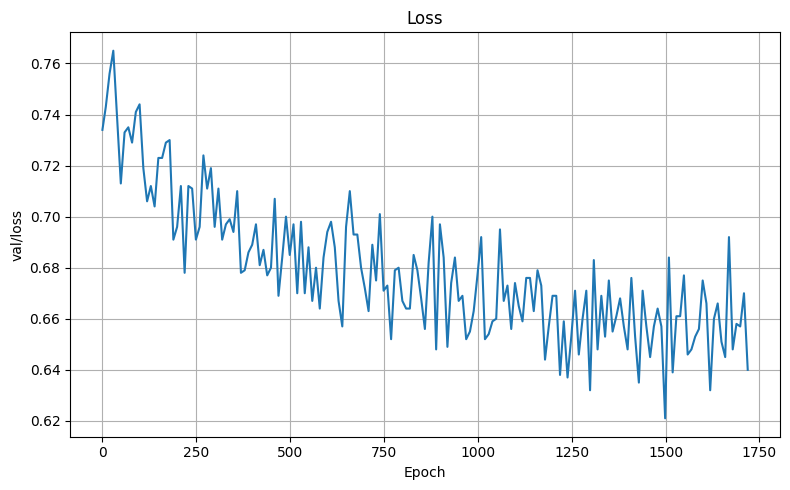

In [6]:
if has_values(losses):
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, losses, marker="")
    plt.xlabel("Epoch")
    plt.ylabel("val/loss")
    plt.title("Loss")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{save_to}/loss.png")
    plt.show()
else:
    print("Skipping val/loss epoch plot: metric not found in this log.")

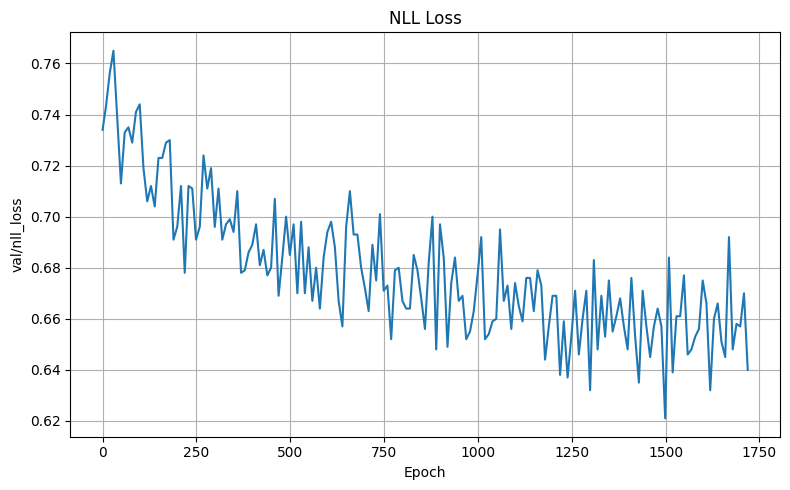

In [7]:
if has_values(nll_loss):
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, nll_loss, marker="")
    plt.xlabel("Epoch")
    plt.ylabel("val/nll_loss")
    plt.title("NLL Loss")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{save_to}/NLL_loss.png")
    plt.show()
else:
    print("Skipping val/nll_loss epoch plot: metric not found in this log.")

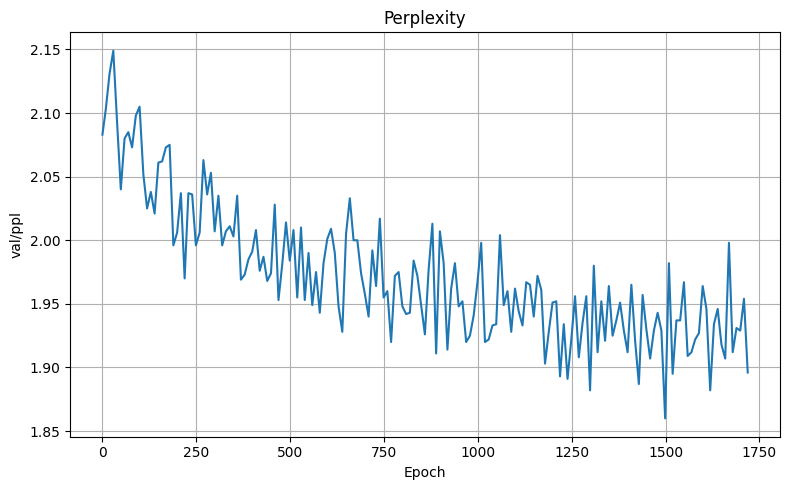

In [8]:
# ChatGPT Summary of ppl metric:
# ppl (Perplexity) — Model-Level Metric
# What it measures: How well the trained language model predicts or generates sequences.
#
# Scope: Evaluates the model's understanding of protein sequence patterns.
#
# When it's used: During training or evaluation of a protein language model (like DPLM).
#
# Lower is better: A lower perplexity indicates the model is more confident and accurate in predicting sequences.

if has_values(ppl):
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, ppl, marker="")
    plt.xlabel("Epoch")
    plt.ylabel("val/ppl")
    plt.title("Perplexity")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{save_to}/perplexity.png")
    plt.show()
else:
    print("Skipping val/ppl epoch plot: metric not found in this log.")

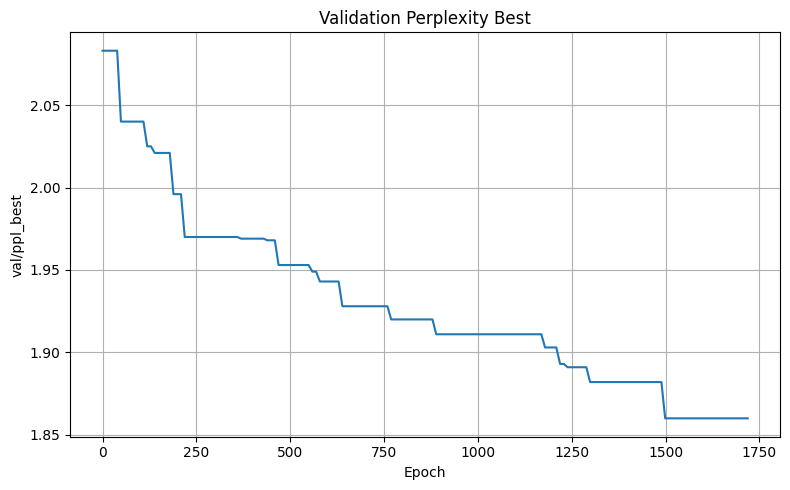

In [9]:
if has_values(ppl_best):
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, ppl_best, marker="")
    plt.xlabel("Epoch")
    plt.ylabel("val/ppl_best")
    plt.title("Validation Perplexity Best")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{save_to}/perplexity_best.png")
    plt.show()
else:
    print("Skipping val/ppl_best epoch plot: metric not found in this log.")

/var/folders/mx/4d2y4srs4qg4brtqkqkls36m0000gn/T/ipykernel_21080/788890776.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


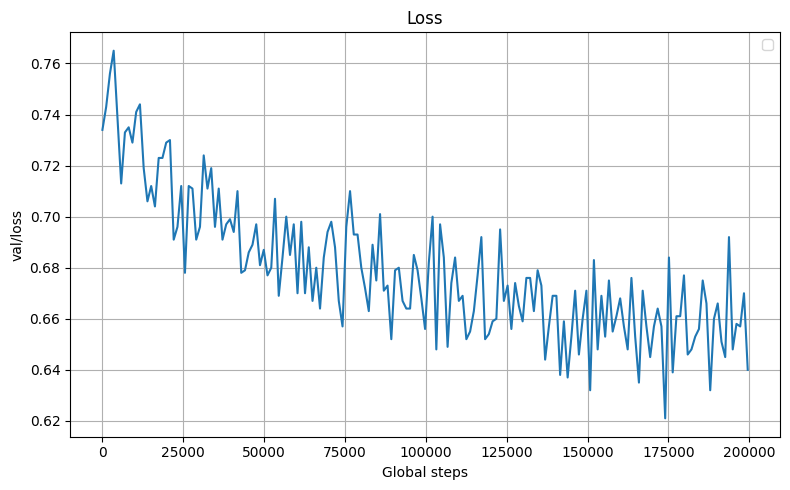

In [10]:
if has_values(losses):
    plt.figure(figsize=(8, 5))
    plt.plot(global_steps, losses, marker="")
    #plt.scatter(checkpoints, [losses[global_steps.index(cp)] for cp in checkpoints], color="red", s=20, zorder=5, label="Checkpoints")
    plt.legend()
    plt.xlabel("Global steps")
    plt.ylabel("val/loss")
    plt.title("Loss")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{save_to}/loss_global_steps.png")
    plt.show()
else:
    print("Skipping val/loss global-step plot: metric not found in this log.")

/var/folders/mx/4d2y4srs4qg4brtqkqkls36m0000gn/T/ipykernel_21080/2269019318.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


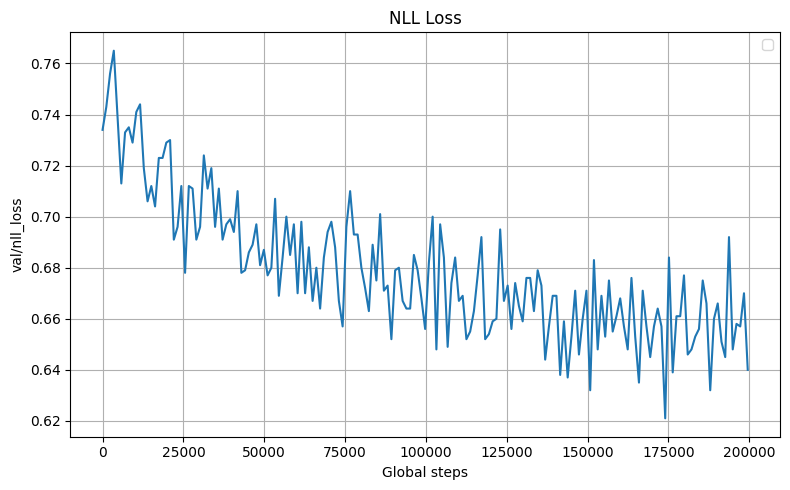

In [11]:
if has_values(nll_loss):
    plt.figure(figsize=(8, 5))
    plt.plot(global_steps, nll_loss, marker="")
    #plt.scatter(checkpoints, [nll_loss[global_steps.index(cp)] for cp in checkpoints], color="red", s=20, zorder=5, label="Checkpoints")
    plt.legend()
    plt.xlabel("Global steps")
    plt.ylabel("val/nll_loss")
    plt.title("NLL Loss")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{save_to}/NLL_loss_global_steps.png")
    plt.show()
else:
    print("Skipping val/nll_loss global-step plot: metric not found in this log.")

/var/folders/mx/4d2y4srs4qg4brtqkqkls36m0000gn/T/ipykernel_21080/3479161123.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


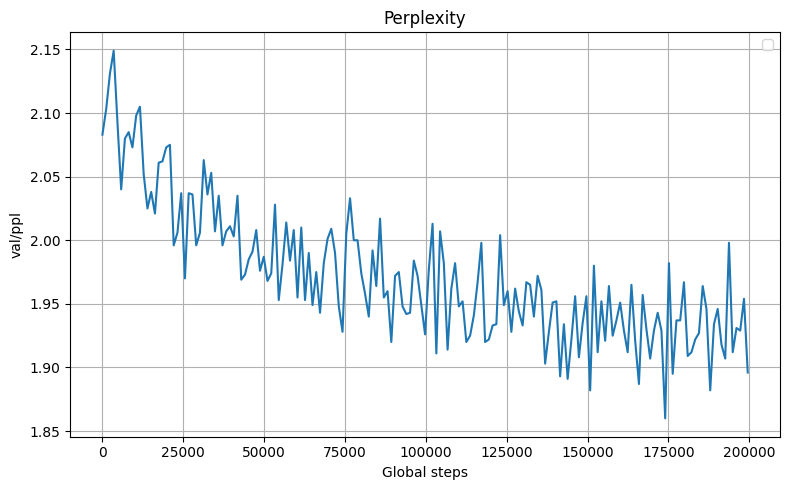

In [12]:
if has_values(ppl):
    plt.figure(figsize=(8, 5))
    plt.plot(global_steps, ppl, marker="")
    #plt.scatter(checkpoints, [ppl[global_steps.index(cp)] for cp in checkpoints], color="red", s=20, zorder=5, label="Checkpoints")
    plt.legend()
    plt.xlabel("Global steps")
    plt.ylabel("val/ppl")
    plt.title("Perplexity")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{save_to}/perplexity_global_steps.png")
    plt.show()
else:
    print("Skipping val/ppl global-step plot: metric not found in this log.")

/var/folders/mx/4d2y4srs4qg4brtqkqkls36m0000gn/T/ipykernel_21080/3848131064.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


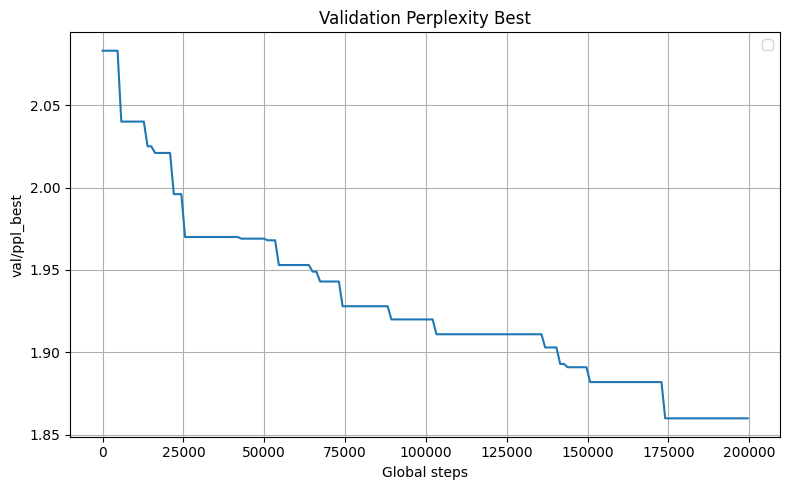

In [13]:
if has_values(ppl_best):
    plt.figure(figsize=(8, 5))
    plt.plot(global_steps, ppl_best, marker="")
    #plt.scatter(checkpoints, [ppl_best[global_steps.index(cp)] for cp in checkpoints], color="red", s=20, zorder=5, label="Checkpoints")
    plt.legend()
    plt.xlabel("Global steps")
    plt.ylabel("val/ppl_best")
    plt.title("Validation Perplexity Best")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{save_to}/perplexity_best_global_steps.png")
    plt.show()
else:
    print("Skipping val/ppl_best global-step plot: metric not found in this log." )

In [14]:
if has_values(acc):
    plt.figure(figsize=(8, 5))
    plt.plot(global_steps, acc, marker="")
    # plt.scatter(checkpoints, [acc[global_steps.index(cp)] for cp in checkpoints], color="red", s=20, zorder=5, label="Checkpoints")
    plt.legend()
    plt.xlabel("Global steps")
    plt.ylabel("val/acc")
    plt.title("Validation Accuracy")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{save_to}/accuracy_global_steps.png")
    plt.show()
else:
    print("Skipping val/acc global-step plot: metric not found in this log.")

Skipping val/acc global-step plot: metric not found in this log.


Scanning local path '/Volumes/data/Users/Matous/terpene_synthases/output/dplm/training/TPS_dplm_150m_stage3_grid_lr1em5_wu2000_lend1em06_winit1em08_loratrue/enzyme_explorer_validation' for CSV files...
Found 18 folders: ['epoch_1', 'epoch_100', 'epoch_200', 'epoch_300', 'epoch_400', 'epoch_500', 'epoch_600', 'epoch_700', 'epoch_800', 'epoch_900', 'epoch_1000', 'epoch_1100', 'epoch_1200', 'epoch_1300', 'epoch_1400', 'epoch_1500', 'epoch_1600', 'epoch_1700']
Processing folder 'epoch_1' with 1 CSV files...
Processing folder 'epoch_100' with 1 CSV files...
Processing folder 'epoch_200' with 1 CSV files...
Processing folder 'epoch_300' with 1 CSV files...
Processing folder 'epoch_400' with 1 CSV files...
Processing folder 'epoch_500' with 1 CSV files...
Processing folder 'epoch_600' with 1 CSV files...
Processing folder 'epoch_700' with 1 CSV files...
Processing folder 'epoch_800' with 1 CSV files...
Processing folder 'epoch_900' with 1 CSV files...
Processing folder 'epoch_1000' with 1 CSV

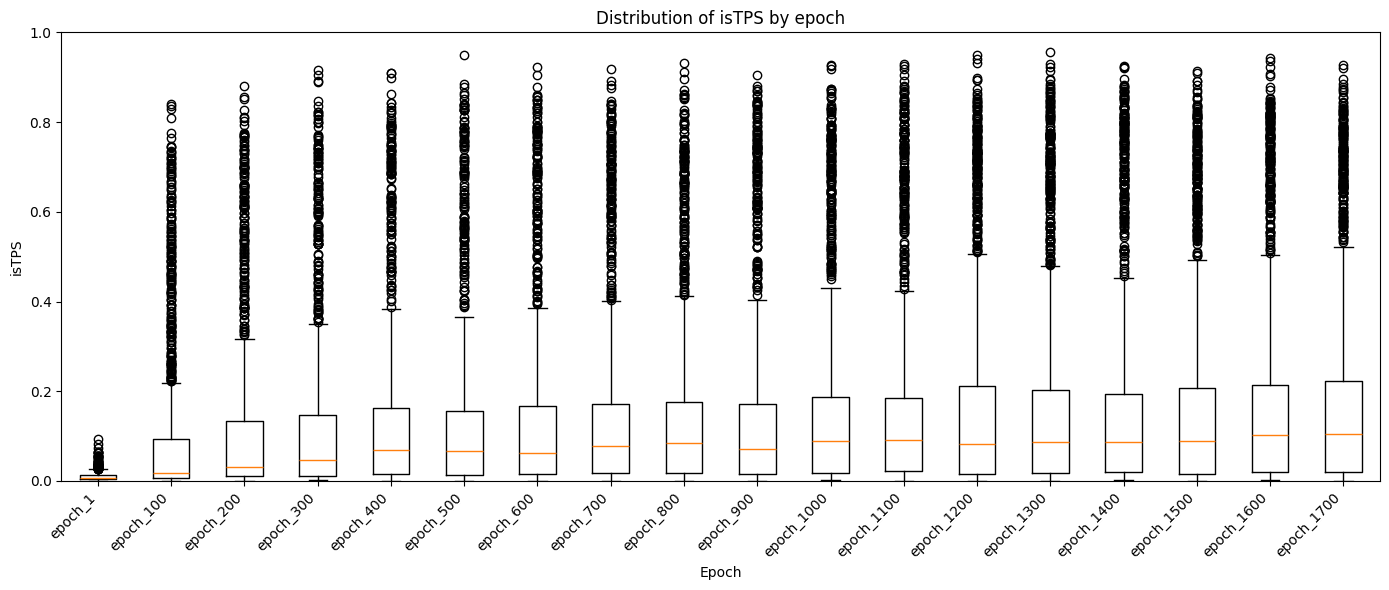

Saved plot to: /Volumes/data/Users/Matous/terpene_synthases/output/dplm/training/TPS_dplm_150m_stage3_grid_lr1em5_wu2000_lend1em06_winit1em08_loratrue/enzyme_explorer_validation/isTPS_by_epoch_boxplot.png


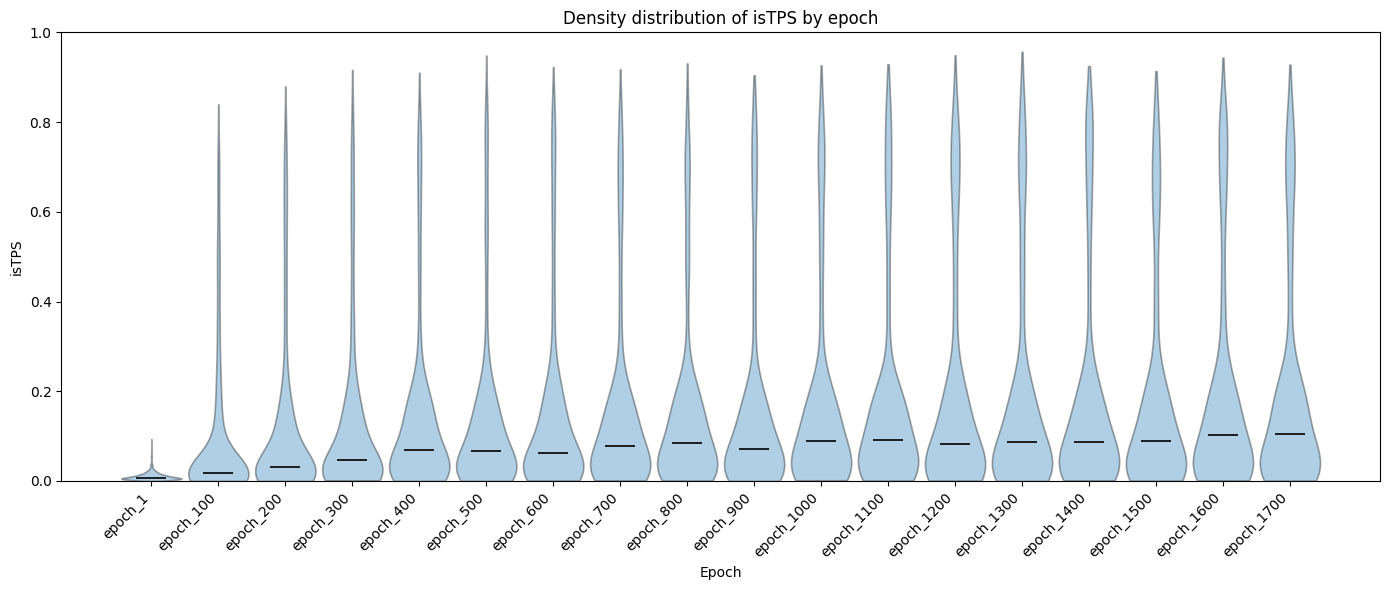

Saved plot to: /Volumes/data/Users/Matous/terpene_synthases/output/dplm/training/TPS_dplm_150m_stage3_grid_lr1em5_wu2000_lend1em06_winit1em08_loratrue/enzyme_explorer_validation/isTPS_by_epoch_violin.png


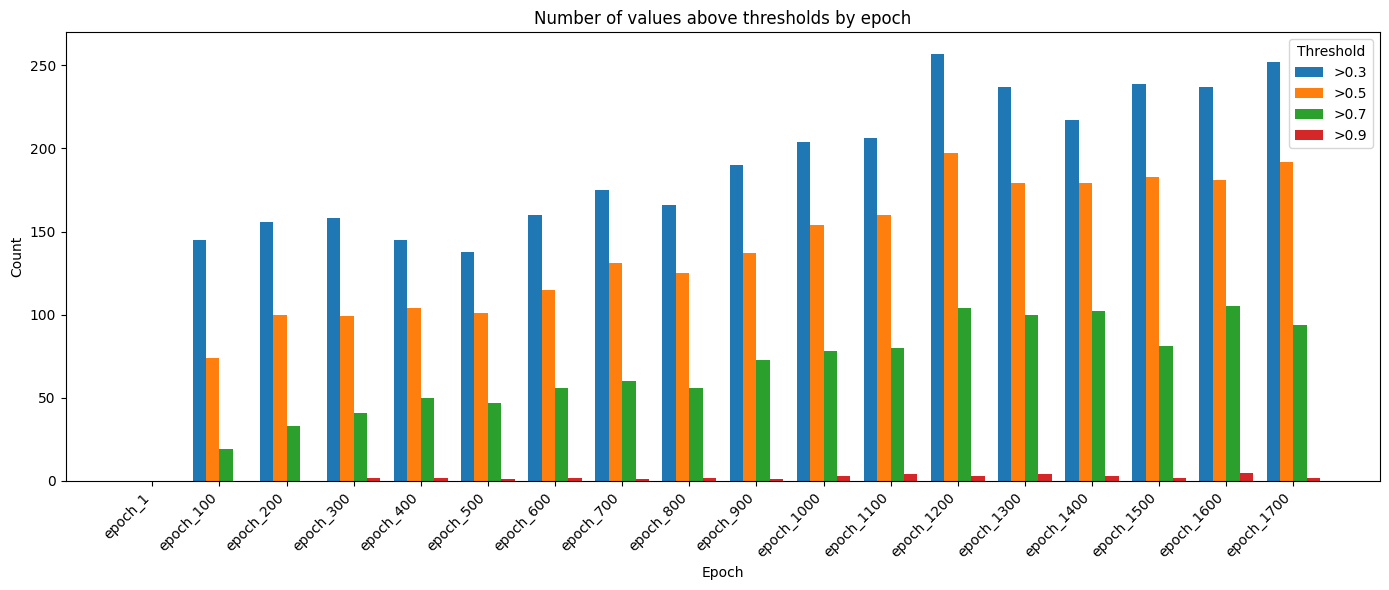

Saved plot to: /Volumes/data/Users/Matous/terpene_synthases/output/dplm/training/TPS_dplm_150m_stage3_grid_lr1em5_wu2000_lend1em06_winit1em08_loratrue/enzyme_explorer_validation/isTPS_by_epoch_counts.png


In [15]:
from pathlib import Path

import numpy as np
import pandas as pd

TARGET_COLUMN_NAME = "isTPS "
enzyme_explorer_path = Path(log_file).resolve().parent / "enzyme_explorer_validation"

if enzyme_explorer_path.exists():
    print(f"Scanning local path '{enzyme_explorer_path}' for CSV files...")
    folders = sorted(
        [path for path in enzyme_explorer_path.iterdir() if path.is_dir()],
        key=lambda path: (0, int(path.name.split("_")[-1]))
        if path.name.startswith("epoch_") and path.name.split("_")[-1].isdigit()
        else (1, path.name),
    )
    print(f"Found {len(folders)} folders: {[folder.name for folder in folders]}")

    rows = []
    for folder in folders:
        csv_files = sorted(folder.glob("*.csv"))
        print(f"Processing folder '{folder.name}' with {len(csv_files)} CSV files...")
        if not csv_files:
            continue

        for csv_file in csv_files:
            try:
                df = pd.read_csv(csv_file)
            except Exception as error:
                print(f"Error reading {csv_file}: {error}")
                continue

            value_column = None
            if TARGET_COLUMN_NAME in df.columns:
                value_column = TARGET_COLUMN_NAME
            else:
                normalized_columns = {column.strip(): column for column in df.columns}
                value_column = normalized_columns.get(TARGET_COLUMN_NAME.strip())

            if value_column is None:
                print(f"Column '{TARGET_COLUMN_NAME}' not found in {csv_file}")
                continue

            values = pd.to_numeric(df[value_column], errors="coerce").dropna()
            rows.extend((folder.name, value) for value in values)

    if rows:
        plot_df = pd.DataFrame(rows, columns=["folder", TARGET_COLUMN_NAME])
        plot_df[TARGET_COLUMN_NAME] = pd.to_numeric(plot_df[TARGET_COLUMN_NAME], errors="coerce")

        available_folders = set(plot_df["folder"])
        folder_order = [folder.name for folder in folders if folder.name in available_folders]
        value_col = TARGET_COLUMN_NAME

        box_data = [
            plot_df.loc[plot_df["folder"] == folder_name, value_col].dropna()
            for folder_name in folder_order
        ]

        fig, ax = plt.subplots(figsize=(14, 6))
        ax.boxplot(box_data, tick_labels=folder_order)
        ax.set_title(f"Distribution of {value_col.strip()} by epoch")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(value_col.strip())
        ax.set_ylim(0.0, 1.0)

        PLOT_LINEAR_FIT = False
        if PLOT_LINEAR_FIT:
            folder_to_x = {folder_name: index + 1 for index, folder_name in enumerate(folder_order)}
            fit_df = plot_df[plot_df["folder"].isin(folder_order)].copy()
            fit_df["x"] = fit_df["folder"].map(folder_to_x)

            x_all = fit_df["x"].to_numpy(dtype=float)
            y_all = fit_df[value_col].to_numpy(dtype=float)
            mask = np.isfinite(x_all) & np.isfinite(y_all)

            if mask.sum() >= 2:
                slope, intercept = np.polyfit(x_all[mask], y_all[mask], 1)
                x_line = np.array([1, len(folder_order)], dtype=float)
                y_line = slope * x_line + intercept
                ax.plot(
                    x_line,
                    y_line,
                    color="crimson",
                    linewidth=2,
                    label=f"Linear fit (all values): y={slope:.4f}x+{intercept:.4f}",
                )
                ax.legend()

        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

        output_file = enzyme_explorer_path / f"{value_col.strip().replace(' ', '_')}_by_epoch_boxplot.png"
        fig.savefig(output_file, dpi=300, bbox_inches="tight")
        print(f"Saved plot to: {output_file}")

        violin_data = [
            pd.to_numeric(
                plot_df.loc[plot_df["folder"] == folder_name, value_col],
                errors="coerce",
            ).dropna().values
            for folder_name in folder_order
        ]

        fig3, ax3 = plt.subplots(figsize=(14, 6))
        parts = ax3.violinplot(
            violin_data,
            positions=np.arange(1, len(folder_order) + 1),
            widths=0.9,
            showmeans=False,
            showmedians=True,
            showextrema=False,
        )

        for body in parts["bodies"]:
            body.set_facecolor("#1f77b4")
            body.set_alpha(0.35)
            body.set_edgecolor("black")
            body.set_linewidth(1.2)

        parts["cmedians"].set_color("black")
        parts["cmedians"].set_linewidth(1.2)

        ax3.set_title(f"Density distribution of {value_col.strip()} by epoch")
        ax3.set_xlabel("Epoch")
        ax3.set_ylabel(value_col.strip())
        ax3.set_ylim(0.0, 1.0)
        ax3.set_xticks(np.arange(1, len(folder_order) + 1))
        ax3.set_xticklabels(folder_order, rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

        output_file = enzyme_explorer_path / f"{value_col.strip().replace(' ', '_')}_by_epoch_violin.png"
        fig3.savefig(output_file, dpi=300, bbox_inches="tight")
        print(f"Saved plot to: {output_file}")

        thresholds = [0.3, 0.5, 0.7, 0.9]
        counts = pd.DataFrame(index=folder_order)
        for threshold in thresholds:
            counts[f">{threshold}"] = plot_df.groupby("folder")[value_col].apply(
                lambda series: (series > threshold).sum()
            )

        counts = counts.reindex(folder_order).fillna(0).astype(int)
        x = np.arange(len(counts.index))
        width = 0.2

        fig2, ax2 = plt.subplots(figsize=(14, 6))
        for index, column in enumerate(counts.columns):
            ax2.bar(
                x + (index - (len(counts.columns) - 1) / 2) * width,
                counts[column].values,
                width=width,
                label=column,
            )

        ax2.set_title("Number of values above thresholds by epoch")
        ax2.set_xlabel("Epoch")
        ax2.set_ylabel("Count")
        ax2.set_xticks(x)
        ax2.set_xticklabels(counts.index, rotation=45, ha="right")
        ax2.legend(title="Threshold")
        plt.tight_layout()
        plt.show()

        output_file = enzyme_explorer_path / f"{value_col.strip().replace(' ', '_')}_by_epoch_counts.png"
        fig2.savefig(output_file, dpi=300, bbox_inches="tight")
        print(f"Saved plot to: {output_file}")

        counts
    else:
        print(f"No usable enzyme explorer values found in: {enzyme_explorer_path}")
else:
    print(f"Skipping enzyme explorer plots because '{enzyme_explorer_path}' does not exist.")
